<a href="https://colab.research.google.com/github/Maria-a21/4lab/blob/master/LAB7%26LAB8_Artymovych.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
# ВАРІАНТ 1 — CITRUS
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [7]:
# 1. Завантажила набір даних9
data = pd.read_csv("citrus.csv")

In [8]:
# 2. Ввела заголовок таблиці (перші 5 записів)
print("Перші 5 записів:")
print(data.head())

Перші 5 записів:
    diameter      weight       red     green      blue        name
0  10.993428  246.308877  0.383741  0.658162  0.287628  grapefruit
1   9.723471  295.470832  0.352284  0.336042  0.214689      orange
2  11.295377  130.071621  0.618215  0.335628  0.243210  grapefruit
3  13.046060  228.148462  0.653238  0.306054  0.335544      orange
4   9.531693  167.467872  0.315793  0.778251  0.521034  grapefruit


In [9]:
# 3. В якому форматі мітки класів?
print("\nТип даних міток класів (стовпець 'name'):")
print(data["name"].dtype)
print("Унікальні мітки класів:")
print(data["name"].unique())


Тип даних міток класів (стовпець 'name'):
object
Унікальні мітки класів:
['grapefruit' 'orange']


In [10]:
# 4. В якому форматі характеристики об’єктів?
#    Чи є характеристики у вигляді тексту? Якщо так, факторизувати
X = data.drop("name", axis=1)

print("\nТипи даних ознак:")
print(X.dtypes)

text_columns = X.select_dtypes(include=["object"]).columns
print("\nТекстові стовпці серед ознак:")
print(list(text_columns))

if len(text_columns) > 0:
    X[text_columns] = X[text_columns].apply(lambda col: pd.factorize(col, sort=True)[0])


Типи даних ознак:
diameter    float64
weight      float64
red         float64
green       float64
blue        float64
dtype: object

Текстові стовпці серед ознак:
[]


In [11]:
# 5. Наскільки збалансовані класи?
print("\nКількість зразків кожного класу:")
print(data["name"].value_counts())

print("\nЧастки класів:")
print(data["name"].value_counts(normalize=True))

# 6. Створити X та Y. Перетворити мітки класів до One Hot Encoding
Y = pd.get_dummies(data["name"], prefix="class")

print("\nПерші 5 рядків X:")
print(X.head())

print("\nПерші 5 рядків Y (One Hot Encoding):")
print(Y.head())


Кількість зразків кожного класу:
name
grapefruit    332
orange        168
Name: count, dtype: int64

Частки класів:
name
grapefruit    0.664
orange        0.336
Name: proportion, dtype: float64

Перші 5 рядків X:
    diameter      weight       red     green      blue
0  10.993428  246.308877  0.383741  0.658162  0.287628
1   9.723471  295.470832  0.352284  0.336042  0.214689
2  11.295377  130.071621  0.618215  0.335628  0.243210
3  13.046060  228.148462  0.653238  0.306054  0.335544
4   9.531693  167.467872  0.315793  0.778251  0.521034

Перші 5 рядків Y (One Hot Encoding):
   class_grapefruit  class_orange
0              True         False
1             False          True
2              True         False
3             False          True
4              True         False


In [12]:
# 7. Розбити набір на навчальну та тестову множини
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.15, random_state=42
)
print(X_train.shape)
print(X_test.shape)

(425, 5)
(75, 5)


In [14]:
# 8. Стандартизувати предиктори X
mean = X_train.mean(axis=0)
std = X_train.std(axis=0)

X_train = (X_train - mean) / std
X_test = (X_test - mean) / std

X_train = X_train.fillna(0)
X_test = X_test.fillna(0)

In [26]:
from tensorflow.keras import Input

# 9. Створити модель нейронної мережі
model = Sequential([
    Input(shape=(X_train.shape[1],)),
    Dense(16, activation="relu"),
    Dense(8, activation="relu"),
    Dense(Y_train.shape[1], activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [16]:
# 10. Навчити нейронну мережу
history = model.fit(
    X_train,
    Y_train,
    epochs=50,
    validation_split=0.15,
    batch_size=16,
    verbose=2
)

Epoch 1/50
23/23 - 2s - 82ms/step - accuracy: 0.6648 - loss: 0.5773 - val_accuracy: 0.5781 - val_loss: 0.5629
Epoch 2/50
23/23 - 0s - 6ms/step - accuracy: 0.6842 - loss: 0.5231 - val_accuracy: 0.6250 - val_loss: 0.5213
Epoch 3/50
23/23 - 0s - 5ms/step - accuracy: 0.7673 - loss: 0.4849 - val_accuracy: 0.8125 - val_loss: 0.4885
Epoch 4/50
23/23 - 0s - 6ms/step - accuracy: 0.8116 - loss: 0.4521 - val_accuracy: 0.8281 - val_loss: 0.4612
Epoch 5/50
23/23 - 0s - 7ms/step - accuracy: 0.8283 - loss: 0.4240 - val_accuracy: 0.8281 - val_loss: 0.4390
Epoch 6/50
23/23 - 0s - 6ms/step - accuracy: 0.8338 - loss: 0.4001 - val_accuracy: 0.8438 - val_loss: 0.4183
Epoch 7/50
23/23 - 0s - 6ms/step - accuracy: 0.8449 - loss: 0.3789 - val_accuracy: 0.8438 - val_loss: 0.3980
Epoch 8/50
23/23 - 0s - 6ms/step - accuracy: 0.8504 - loss: 0.3584 - val_accuracy: 0.8750 - val_loss: 0.3779
Epoch 9/50
23/23 - 0s - 6ms/step - accuracy: 0.8615 - loss: 0.3383 - val_accuracy: 0.8906 - val_loss: 0.3571
Epoch 10/50
23/23 

In [17]:
# 11. Оцінити якість на тестовій множині
loss, accuracy = model.evaluate(X_test, Y_test, verbose=0)

print("\nРезультати на тестовій множині:")
print(f"Loss = {loss:.4f}")
print(f"Accuracy = {accuracy:.4f}")


Результати на тестовій множині:
Loss = 0.0482
Accuracy = 0.9867


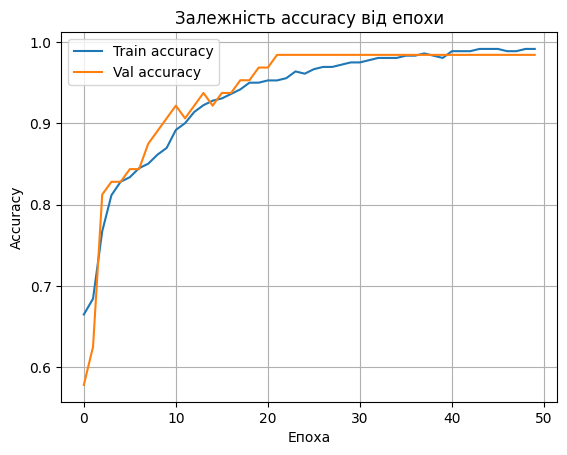

In [18]:
# 12. Побудувати графік залежності метрики від епохи
plt.plot(history.history["accuracy"], label="Train accuracy")
plt.plot(history.history["val_accuracy"], label="Val accuracy")
plt.title("Залежність accuracy від епохи")
plt.xlabel("Епоха")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()


In [19]:
# 13. Подати довільний зразок із тестової вибірки
sample = X_test.iloc[0:1]
prediction = model.predict(sample, verbose=0)

score = np.max(prediction)
predicted_class_index = np.argmax(prediction)
true_class_index = np.argmax(Y_test.iloc[0:1].values)

class_names = list(Y.columns)
predicted_class_name = class_names[predicted_class_index]
true_class_name = class_names[true_class_index]

print("\nРезультат для одного зразка:")
print(f"Передбачено клас {predicted_class_name} з достовірністю {score * 100:.2f}%")
print(f"Правильний клас: {true_class_name}")



Результат для одного зразка:
Передбачено клас class_grapefruit з достовірністю 100.00%
Правильний клас: class_grapefruit


In [20]:
# Збереження моделі
model.save("citrus_model.h5")
print("\nМодель збережено у файл citrus_model.h5")


Модель збережено у файл citrus_model.h5


In [21]:
# =========================
# ЛАБА 8
# =========================

# Оцінка базової моделі (з лаби 7)
loss, acc = model.evaluate(X_test, Y_test)
print("Базова точність:", acc)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9867 - loss: 0.0482
Базова точність: 0.9866666793823242


In [22]:
# 1. Оптимізація: Dropout

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

model_dropout = Sequential()
model_dropout.add(Dense(10, input_dim=X_train.shape[1], activation="relu"))
model_dropout.add(Dropout(0.2))  # відключає 20% нейронів
model_dropout.add(Dense(Y_train.shape[1], activation="softmax"))

model_dropout.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

history_dropout = model_dropout.fit(
    X_train, Y_train,
    epochs=50,
    validation_split=0.15
)

loss_d, acc_d = model_dropout.evaluate(X_test, Y_test)
print("Точність з Dropout:", acc_d)


Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.2936 - loss: 1.1718 - val_accuracy: 0.4219 - val_loss: 1.0772
Epoch 2/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.3130 - loss: 1.0845 - val_accuracy: 0.4219 - val_loss: 1.0217
Epoch 3/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.3047 - loss: 1.0423 - val_accuracy: 0.4219 - val_loss: 0.9717
Epoch 4/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.2936 - loss: 0.9991 - val_accuracy: 0.4219 - val_loss: 0.9252
Epoch 5/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.3324 - loss: 0.9096 - val_accuracy: 0.4375 - val_loss: 0.8839
Epoch 6/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.3878 - loss: 0.8768 - val_accuracy: 0.4375 - val_loss: 0.8461
Epoch 7/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4238 - loss: 0.8348 - val_accuracy: 0.5000 - val_loss: 0.8120
Epoch 8/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4321 - loss: 0.8172 - val_accuracy: 0.4844 - val_loss: 0.7818


In [23]:
# 2. Оптимізація: EarlyStopping


from tensorflow.keras.callbacks import EarlyStopping

early = EarlyStopping(monitor='val_loss', patience=5)

model_early = Sequential()
model_early.add(Dense(10, input_dim=X_train.shape[1], activation="relu"))
model_early.add(Dense(Y_train.shape[1], activation="softmax"))

model_early.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

history_early = model_early.fit(
    X_train, Y_train,
    epochs=50,
    validation_split=0.15,
    callbacks=[early]
)

loss_e, acc_e = model_early.evaluate(X_test, Y_test)
print("Точність з EarlyStopping:", acc_e)

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - accuracy: 0.5706 - loss: 0.7830 - val_accuracy: 0.6094 - val_loss: 0.7233
Epoch 2/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6150 - loss: 0.7375 - val_accuracy: 0.5938 - val_loss: 0.6980
Epoch 3/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6316 - loss: 0.6958 - val_accuracy: 0.6094 - val_loss: 0.6757
Epoch 4/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6454 - loss: 0.6634 - val_accuracy: 0.6094 - val_loss: 0.6549
Epoch 5/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6565 - loss: 0.6330 - val_accuracy: 0.6250 - val_loss: 0.6365
Epoch 6/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.6814 - loss: 0.6081 - val_accuracy: 0.6406 - val_loss: 0.6182
Epoch 7/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6898 - loss: 0.5851 - val_accuracy: 0.6406 - val_loss: 0.6019
Epoch 8/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7064 - loss: 0.5667 - val_accuracy: 0.6719 - val_loss: 0.5861

In [24]:
# 3. Оптимізація: зміна архітектури

model_simple = Sequential()
model_simple.add(Dense(6, input_dim=X_train.shape[1], activation="relu"))  # менше нейронів
model_simple.add(Dense(Y_train.shape[1], activation="softmax"))

model_simple.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

history_simple = model_simple.fit(
    X_train, Y_train,
    epochs=50,
    validation_split=0.15
)

loss_s, acc_s = model_simple.evaluate(X_test, Y_test)
print("Точність спрощеної моделі:", acc_s)

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.6233 - loss: 0.7532 - val_accuracy: 0.5938 - val_loss: 0.8249
Epoch 2/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6399 - loss: 0.7322 - val_accuracy: 0.5938 - val_loss: 0.8018
Epoch 3/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6482 - loss: 0.7114 - val_accuracy: 0.5938 - val_loss: 0.7815
Epoch 4/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6648 - loss: 0.6935 - val_accuracy: 0.5938 - val_loss: 0.7622
Epoch 5/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.6787 - loss: 0.6763 - val_accuracy: 0.5938 - val_loss: 0.7441
Epoch 6/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6870 - loss: 0.6589 - val_accuracy: 0.5938 - val_loss: 0.7271
Epoch 7/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.6925 - loss: 0.6428 - val_accuracy: 0.5938 - val_loss: 0.7105
Epoch 8/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.6953 - loss: 0.6279 - val_accuracy: 0.6094 - val_loss: 0.